# DR-Learner 实验结果解析（重组版）

按顺序五块：

1. **特征筛选**：有粗/细筛 CSV 或 `feature_selection_summary.json` 则展示；否则跳过或仅展示 `selected_features.txt`。
2. **各渠道模型**：`base_model_scores.json`、`lead_leaderboard.json`、`best_model_params.json`。
3. **ITE 质量**：**仅**用 `test_predictions.csv` / `test_predictions_total.csv` 重算；**`N_BINS`** 控制 `decile_r` 与 rank **decile R²**（散点图为 **箱内 mean(pred) vs 箱内观测 ATE**，即 **E[Y|T=1]−E[Y|T=0]**，非 mean Y）；**不**以 `ite_quality_*.json` 为主表。
4. **Propensity（Val + Test 指标）**：Val 候选；Test 上 `log_loss` / `ece` / `auc`（需 `propensity_score` 列）。
5. **Propensity 重叠（可视化）**：Test 上 T=0 / T=1 的 `propensity_score` 分布重叠与分位对比，侧重 common support。

**用法**：改下一格的 `EXP_DIR` 为实验输出目录绝对路径，**Run All**。

表格高亮「选中」模型需 **`jinja2`**；未安装时会出现 **`_is_best`** 列。


In [12]:
from pathlib import Path

# 实验输出目录（绝对路径）
EXP_DIR = Path("/Users/jialuliang/Documents/WorkMagic/lift_test_calibration/feature_engineering/_model_build/output/20260323_020322")


In [13]:
import json

import pandas as pd
from IPython.display import Markdown, display


def _styler_ok() -> bool:
    try:
        import jinja2  # noqa: F401
    except ImportError:
        return False
    return True


def discover_channels(exp_dir: Path) -> list[str]:
    """子目录含 test_predictions.csv 即视为渠道。"""
    exp_dir = Path(exp_dir)
    out: list[str] = []
    for p in sorted(exp_dir.iterdir()):
        if p.is_dir() and (p / "test_predictions.csv").exists():
            out.append(p.name)
    return out


def load_json(path: Path):
    path = Path(path)
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    return None


def style_kind_best(df: pd.DataFrame, kind_col: str, best: str | None):
    if df.empty or not best or kind_col not in df.columns:
        return df
    if not _styler_ok():
        out = df.copy()
        out["_is_best"] = out[kind_col] == best
        return out

    def _row(r):
        if r[kind_col] == best:
            return ["background-color: #d4edda"] * len(r)
        return [""] * len(r)

    return df.style.apply(_row, axis=1)


def style_family_best(df: pd.DataFrame, best_family: str | None):
    if df.empty or not best_family or "family" not in df.columns:
        return df
    if not _styler_ok():
        out = df.copy()
        out["_is_best"] = out["family"] == best_family
        return out

    def _row(r):
        if r["family"] == best_family:
            return ["background-color: #d4edda"] * len(r)
        return [""] * len(r)

    return df.style.apply(_row, axis=1)


channels = discover_channels(EXP_DIR)
print("EXP_DIR:", EXP_DIR.resolve())
print("Channels:", channels)
if not channels:
    print("未发现含 test_predictions.csv 的渠道子目录 — 请检查 EXP_DIR。")


EXP_DIR: /Users/jialuliang/Documents/WorkMagic/lift_test_calibration/feature_engineering/_model_build/output/20260323_020322
Channels: ['applovin', 'google', 'meta', 'microsoft', 'other', 'pinterest', 'snapchat', 'tiktok']


## Part 1 — 特征筛选

按渠道展示；若无 `feature_importance_*.csv` 则提示并尽量展示 `selected_features.txt`。


In [14]:
for ch in channels:
    display(Markdown(f"---\n## 渠道 `{ch}` — 特征筛选"))

    display(
        Markdown(
            "1. **Val 粗筛**：`feature_importance_val.csv`；`feature_selection_summary.json` 可提供 `coarse_top_n`、`n_protected` 等。\n"
            "2. **Train 细筛**：`feature_importance_train_on_coarse.csv`；`fine_top_k`。\n"
            "行顺序为 FilterSelect rank；`_kept_after_*` 仅为按前 N 行截断示意，最终以 `selected_features.txt` 与 summary 为准。"
        )
    )

    summ_path = EXP_DIR / ch / "feature_selection_summary.json"
    imp_v = EXP_DIR / ch / "feature_importance_val.csv"
    imp_t = EXP_DIR / ch / "feature_importance_train_on_coarse.csv"
    sf_path = EXP_DIR / ch / "selected_features.txt"
    summ = load_json(summ_path) if summ_path.exists() else None

    has_stage = imp_v.exists() or imp_t.exists() or summ_path.exists()

    if summ:
        display(Markdown("**`feature_selection_summary.json`**"))
        display(pd.DataFrame([summ]))
    elif has_stage:
        display(Markdown("*未找到 `feature_selection_summary.json`。*"))
    else:
        display(
            Markdown(
                "*未落盘粗/细筛 CSV/summary（例如全量特征或未保存中间表）。若存在 `selected_features.txt` 见下文。*"
            )
        )

    coarse_n = int(summ["coarse_top_n"]) if summ and summ.get("coarse_top_n") is not None else None
    fine_k = int(summ["fine_top_k"]) if summ and summ.get("fine_top_k") is not None else None

    if imp_v.exists():
        dfv = pd.read_csv(imp_v).reset_index(drop=True)
        if coarse_n is not None and coarse_n > 0:
            dfv = dfv.copy()
            dfv["_kept_after_coarse"] = dfv.index < coarse_n
        display(
            Markdown(
                f"**Val — `feature_importance_val.csv`**：共 **{len(dfv)}** 行。"
                + (
                    f" `_kept_after_coarse`：前 **{coarse_n}** 行示意进入粗筛子集。"
                    if coarse_n
                    else ""
                )
            )
        )
        display(dfv.head(80))
        if len(dfv) > 80:
            display(Markdown("*… 最后 20 行 …*"))
            display(dfv.tail(20))
    else:
        display(Markdown("*无 `feature_importance_val.csv`*"))

    if imp_t.exists():
        dft = pd.read_csv(imp_t).reset_index(drop=True)
        if fine_k is not None and fine_k > 0:
            dft = dft.copy()
            dft["_kept_after_fine"] = dft.index < fine_k
        display(
            Markdown(
                f"**Train — `feature_importance_train_on_coarse.csv`**：共 **{len(dft)}** 行。"
                + (f" `_kept_after_fine`：前 **{fine_k}** 行示意。" if fine_k else "")
            )
        )
        display(dft.head(80))
        if len(dft) > 80:
            display(Markdown("*… 最后 20 行 …*"))
            display(dft.tail(20))
    else:
        display(Markdown("*无 `feature_importance_train_on_coarse.csv`*"))

    if sf_path.exists():
        names = [ln.strip() for ln in sf_path.read_text(encoding="utf-8").splitlines() if ln.strip()]
        display(Markdown(f"**`selected_features.txt`**：**{len(names)}** 个特征"))
        display(pd.DataFrame({"order": range(1, len(names) + 1), "feature": names}).head(150))
        if len(names) > 150:
            display(Markdown(f"*仅展示前 150；共 {len(names)} 个。*"))
        if summ and summ.get("n_selected") is not None and int(summ["n_selected"]) != len(names):
            display(
                Markdown(
                    f"*注意：`n_selected`={summ['n_selected']} 与 txt 行数 {len(names)} 不一致。*"
                )
            )
    else:
        display(Markdown("*无 `selected_features.txt`*"))

if not channels:
    display(Markdown("*无渠道，跳过 Part 1。*"))


---
## 渠道 `applovin` — 特征筛选

1. **Val 粗筛**：`feature_importance_val.csv`；`feature_selection_summary.json` 可提供 `coarse_top_n`、`n_protected` 等。
2. **Train 细筛**：`feature_importance_train_on_coarse.csv`；`fine_top_k`。
行顺序为 FilterSelect rank；`_kept_after_*` 仅为按前 N 行截断示意，最终以 `selected_features.txt` 与 summary 为准。

*未落盘粗/细筛 CSV/summary（例如全量特征或未保存中间表）。若存在 `selected_features.txt` 见下文。*

*无 `feature_importance_val.csv`*

*无 `feature_importance_train_on_coarse.csv`*

...

*未落盘粗/细筛 CSV/summary（例如全量特征或未保存中间表）。若存在 `selected_features.txt` 见下文。*

*无 `feature_importance_val.csv`*

*无 `feature_importance_train_on_coarse.csv`*

**`selected_features.txt`**：**80** 个特征

,order,feature
0,1,day_name_unknown
1,2,month
2,3,quarter
3,4,is_weekday
4,5,day
...,...,...
75,76,emb_event_8
76,77,emb_event_4
77,78,inferred_interests
78,79,emb_user_base_7


## Part 2 — 各渠道模型参数与指标

来源：各渠道目录下 JSON（与 `N_BINS` 无关）。


In [15]:
for ch in channels:
    display(Markdown(f"---\n## 渠道 `{ch}` — 模型"))

    base = load_json(EXP_DIR / ch / "base_model_scores.json")
    if base:
        dfp = pd.DataFrame(base.get("propensity_scores") or [])
        dfo = pd.DataFrame(base.get("outcome_scores") or [])
        display(Markdown("**倾向模型候选（Val）** — 绿色 = `best_propensity_kind`"))
        display(style_kind_best(dfp, "kind", base.get("best_propensity_kind")))
        display(Markdown("**结果模型候选（Val）** — 绿色 = `best_outcome_kind`"))
        display(style_kind_best(dfo, "kind", base.get("best_outcome_kind")))
    else:
        display(Markdown("*无 `base_model_scores.json`*"))

    lb = load_json(EXP_DIR / ch / "lead_leaderboard.json")
    bp = load_json(EXP_DIR / ch / "best_model_params.json")
    if isinstance(lb, list) and lb:
        rows = []
        for x in lb:
            row = {"family": x.get("family"), "val_mse": x.get("val_mse")}
            row["params_json"] = json.dumps(x.get("params"), ensure_ascii=False)
            rows.append(row)
        dflb = pd.DataFrame(rows)
        bf = bp.get("family") if isinstance(bp, dict) else None
        display(Markdown("**Lead Optuna（Val MSE）** — 绿色 = 选中族"))
        display(style_family_best(dflb, bf))
    else:
        display(Markdown("*无 `lead_leaderboard.json`*"))

    if isinstance(bp, dict) and bp:
        display(Markdown("**选中 Lead — `best_model_params.json`**"))
        display(pd.DataFrame([bp]))
    else:
        display(Markdown("*无 `best_model_params.json`*"))

if not channels:
    display(Markdown("*无渠道，跳过 Part 2。*"))


---
## 渠道 `applovin` — 模型

**倾向模型候选（Val）** — 绿色 = `best_propensity_kind`

,kind,log_loss,ece
0,lr,0.228537,0.018063
1,xgb,0.232011,0.023124


**结果模型候选（Val）** — 绿色 = `best_outcome_kind`

,kind,mse,auc
0,lgbm,0.118397,0.672788
1,rf,0.118297,0.674237


...

,kind,mse,auc
0,lgbm,0.118567,0.667737
1,rf,0.118503,0.668183


**Lead Optuna（Val MSE）** — 绿色 = 选中族

,family,val_mse,params_json
0,lgbm,0.414269,"{""n_estimators"": 83, ""max_depth"": 6, ""learning_rate"": 0.020691510266173687, ""num_leaves"": 104, ""val_mse"": 0.414269155692662}"
1,xgb,0.415209,"{""n_estimators"": 106, ""max_depth"": 6, ""learning_rate"": 0.021648036763001914, ""subsample"": 0.9637281608315128, ""colsample_bytree"": 0.7035119926400067, ""val_mse"": 0.4152091328322304}"
2,rf,0.414903,"{""n_estimators"": 236, ""max_depth"": 4, ""min_samples_leaf"": 20, ""val_mse"": 0.41490349957974776}"


**选中 Lead — `best_model_params.json`**

,family,n_estimators,max_depth,learning_rate,num_leaves,val_mse
0,lgbm,83,6,0.020692,104,0.414269


## Part 3 — ITE 质量（CSV 重算）

- **旋钮**：下方 **`N_BINS`** — 用于 **`decile_r`**（渠道）与 **rank decile R²** 散点图（渠道 + Total）。
- **decile R²**：按 pred（或 Total 的 `ITE_total`）排名分箱后，横轴为箱内 **mean(pred)**，纵轴为箱内 **观测 ATE** `E[Y|T=1]−E[Y|T=0]`（需 `T_*`）；**不是** 箱内 mean Y（conversion）。Total 的 CSV 若无 `T_*` 则汇总表该项与 Total 图会跳过或提示。
- **不用** `ite_quality_test.json` / `ite_quality_total.json` **做主指标**（可与文末对照）。
- **数据**：`{ch}/test_predictions.csv`，根目录 `test_predictions_total.csv`。


### 渠道 ITE 指标（自算，`n_bins=50`）

,channel,auuc_qini,decile_r,n_bins,ate_pred_mean,ate_obs_ate,ate_ate_diff
0,applovin,0.064679,-0.014569,50,-0.051710,-0.065077,0.013367
1,google,-0.084047,0.939226,50,0.090922,0.106519,-0.015597
2,meta,-0.052792,-0.418415,50,0.008634,0.060258,-0.051624
3,microsoft,-0.093895,0.363478,50,0.083517,0.016490,0.067027
4,other,0.019638,0.922384,50,-0.008997,-0.076816,0.067819
5,pinterest,0.171680,0.135674,50,-0.095045,-0.104555,0.009510
6,snapchat,-0.050437,0.061577,50,-0.066620,-0.024688,-0.041933
7,tiktok,0.025244,0.073976,50,-0.081861,-0.101970,0.020109


### Total ITE 指标（自算）

,layer,conversion_qini,decile_r2_mean_ite_vs_mean_y,sample_corr_sq,n_bins
0,Total,0.091871,0.036452,0.004233,50


/var/folders/nh/lk_mqzl50zn_7c5jv8rt6l680000gn/T/ipykernel_52305/2801133575.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


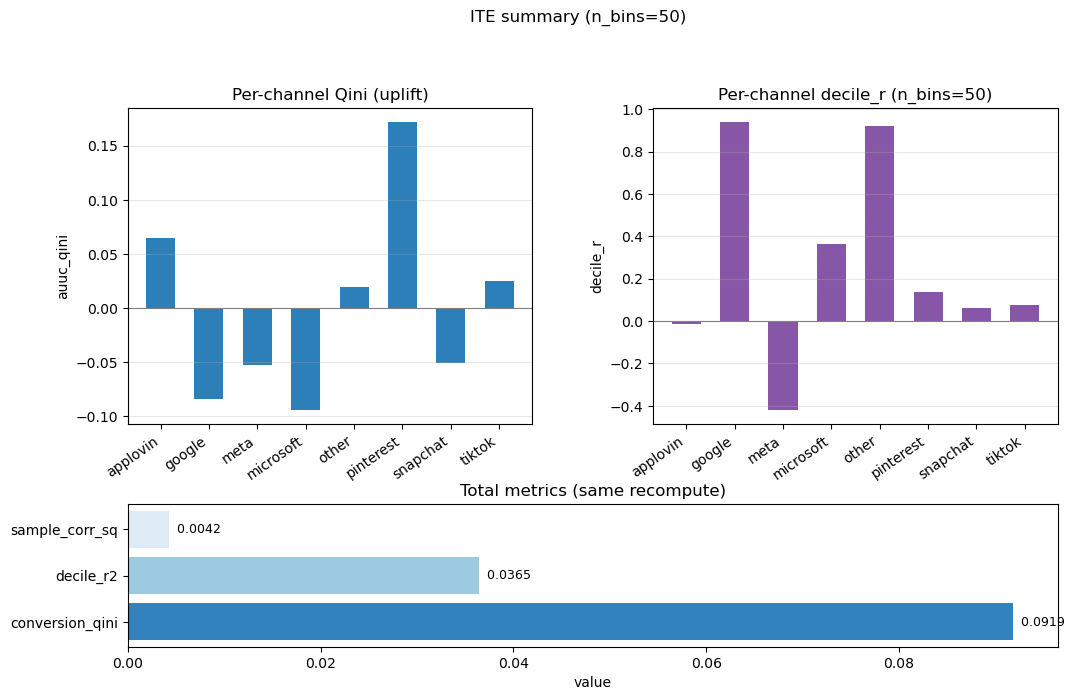

*对照：`ite_quality_total.json` 为训练落盘（`n_bins`=10），与上表自算可能不一致。*

In [16]:
import sys

import matplotlib.pyplot as plt
import numpy as np

# ----- 唯一分箱旋钮 -----
N_BINS = 50
N_RANDOM_QINI = 20
SEED = 42


def _ensure_model_build_on_path(exp_dir: Path) -> Path:
    p = Path(exp_dir).resolve()
    if p.parent.name == "output":
        grand = p.parent.parent
        if grand.name == "_model_build":
            mb = grand.parent / "model_build"
        elif grand.name == "model_build":
            mb = grand
        else:
            mb = grand
    else:
        mb = p.parent.parent
    s = str(mb)
    if s not in sys.path:
        sys.path.insert(0, s)
    return mb


_ensure_model_build_on_path(EXP_DIR)

from dr_learner_pipeline.metrics_total import conversion_qini_vs_random, decile_r2_score
from utils.ite_quality import (
    compute_ate_calibration,
    compute_decile_consistency,
    compute_qini_auc,
)


def _conversion_by_bins_decile(
    score: np.ndarray, y: np.ndarray, n_bins: int
) -> pd.DataFrame:
    """与 metrics_total.conversion_by_bins 一致。"""
    score = np.asarray(score, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    n = len(score)
    order = np.argsort(-score)
    ranks = np.empty(n, dtype=int)
    ranks[order] = np.arange(n)
    bin_id = np.minimum((ranks * n_bins) // n, n_bins - 1)
    rows = []
    for b in range(n_bins):
        m = bin_id == b
        if not m.any():
            rows.append({"bin": b, "n": 0, "mean_score": np.nan, "conversion_rate": np.nan})
        else:
            rows.append(
                {
                    "bin": b,
                    "n": int(m.sum()),
                    "mean_score": float(np.mean(score[m])),
                    "conversion_rate": float(np.mean(y[m])),
                }
            )
    return pd.DataFrame(rows)


def _decile_r2_unweighted(mean_score: np.ndarray, mean_y: np.ndarray) -> float:
    m = np.isfinite(mean_score) & np.isfinite(mean_y)
    x = mean_score[m]
    yy = mean_y[m]
    if len(x) < 3:
        return float("nan")
    x_mean = x.mean()
    y_mean = yy.mean()
    beta = np.sum((x - x_mean) * (yy - y_mean)) / (np.sum((x - x_mean) ** 2) + 1e-12)
    alpha = y_mean - beta * x_mean
    pred = alpha + beta * x
    ss_res = np.sum((yy - pred) ** 2)
    ss_tot = np.sum((yy - y_mean) ** 2)
    if ss_tot < 1e-12:
        return 0.0
    return float(1.0 - ss_res / ss_tot)


chs = list(channels)
if not chs:
    chs = [
        p.name
        for p in sorted(EXP_DIR.iterdir())
        if p.is_dir() and (p / "test_predictions.csv").exists()
    ]

ch_rows = []
for ch in chs:
    csvp = EXP_DIR / ch / "test_predictions.csv"
    if not csvp.exists():
        continue
    d = pd.read_csv(csvp)
    tcols = [c for c in d.columns if c.startswith("T_")]
    if not tcols or "pred_ite" not in d.columns or "Y" not in d.columns:
        continue
    tcol = f"T_{ch}" if f"T_{ch}" in d.columns else tcols[0]
    pred = d["pred_ite"].to_numpy(dtype=float)
    T = d[tcol].to_numpy()
    Y = d["Y"].to_numpy(dtype=float)
    ate = compute_ate_calibration(pred, T, Y)
    qini = compute_qini_auc(pred, T, Y)
    dec = compute_decile_consistency(pred, T, Y, n_bins=N_BINS)
    row = {"channel": ch, "auuc_qini": qini, "decile_r": dec["decile_r"], "n_bins": N_BINS}
    row.update({f"ate_{k}": v for k, v in ate.items()})
    ch_rows.append(row)

ch_df = pd.DataFrame(ch_rows)
display(Markdown(f"### 渠道 ITE 指标（自算，`n_bins={N_BINS}`）"))
display(ch_df if not ch_df.empty else "(无 test_predictions.csv)")

tot_p = EXP_DIR / "test_predictions_total.csv"
tot_row = None
if tot_p.exists():
    dt = pd.read_csv(tot_p)
    if "ITE_total" in dt.columns and "Y" in dt.columns:
        ite = dt["ITE_total"].to_numpy(dtype=float)
        y = dt["Y"].to_numpy(dtype=float)
        qini_t, _ = conversion_qini_vs_random(ite, y, n_random=N_RANDOM_QINI, seed=SEED)
        r2 = decile_r2_score(ite, y, n_bins=N_BINS)
        try:
            c0 = np.corrcoef(ite, y)[0, 1]
            corr_sq = float(c0**2) if c0 == c0 else float("nan")
        except Exception:
            corr_sq = float("nan")
        tot_row = {
            "layer": "Total",
            "conversion_qini": qini_t,
            "decile_r2_mean_ite_vs_mean_y": r2,
            "sample_corr_sq": corr_sq,
            "n_bins": N_BINS,
        }
        display(Markdown("### Total ITE 指标（自算）"))
        display(pd.DataFrame([tot_row]))
else:
    display(Markdown("*无 `test_predictions_total.csv`，跳过 Total 表。*"))

# ----- 一张汇总图：渠道 auuc_qini / decile_r + Total 水平条 -----
if not ch_df.empty:
    fig = plt.figure(figsize=(12, 7))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 0.45], hspace=0.35, wspace=0.3)
    ax_q = fig.add_subplot(gs[0, 0])
    ax_d = fig.add_subplot(gs[0, 1])
    ax_t = fig.add_subplot(gs[1, :])

    x = np.arange(len(ch_df))
    ax_q.bar(x, ch_df["auuc_qini"], 0.6, label="auuc_qini", color="#2c7fb8")
    ax_q.set_xticks(x)
    ax_q.set_xticklabels(ch_df["channel"], rotation=35, ha="right")
    ax_q.set_ylabel("auuc_qini")
    ax_q.set_title("Per-channel Qini (uplift)")
    ax_q.axhline(0, color="gray", lw=0.8)
    ax_q.grid(True, axis="y", alpha=0.3)

    ax_d.bar(x, ch_df["decile_r"], 0.6, label="decile_r", color="#8856a7")
    ax_d.set_xticks(x)
    ax_d.set_xticklabels(ch_df["channel"], rotation=35, ha="right")
    ax_d.set_ylabel("decile_r")
    ax_d.set_title(f"Per-channel decile_r (n_bins={N_BINS})")
    ax_d.axhline(0, color="gray", lw=0.8)
    ax_d.grid(True, axis="y", alpha=0.3)

    if tot_row:
        keys = ["conversion_qini", "decile_r2_mean_ite_vs_mean_y", "sample_corr_sq"]
        labels = ["conversion_qini", "decile_r2", "sample_corr_sq"]
        vals = [float(tot_row[k]) if tot_row[k] == tot_row[k] else 0.0 for k in keys]
        ypos = np.arange(len(labels))
        ax_t.barh(ypos, vals, color=["#3182bd", "#9ecae1", "#deebf7"])
        ax_t.set_yticks(ypos)
        ax_t.set_yticklabels(labels)
        ax_t.set_xlabel("value")
        ax_t.set_title("Total metrics (same recompute)")
        for i, v in enumerate(vals):
            ax_t.text(v, i, f"  {v:.4f}", va="center", fontsize=9)
    else:
        ax_t.text(0.5, 0.5, "No Total row", ha="center", va="center", transform=ax_t.transAxes)

    fig.suptitle(f"ITE summary (n_bins={N_BINS})", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("*无渠道指标，跳过汇总条形图。*"))

# 可选：与落盘 json 对照（训练时 n_rank_bins 可能不同）
jq_t = load_json(EXP_DIR / "ite_quality_total.json")
if jq_t:
    display(
        Markdown(
            f"*对照：`ite_quality_total.json` 为训练落盘（`n_bins`={jq_t.get('n_bins')}），与上表自算可能不一致。*"
        )
    )


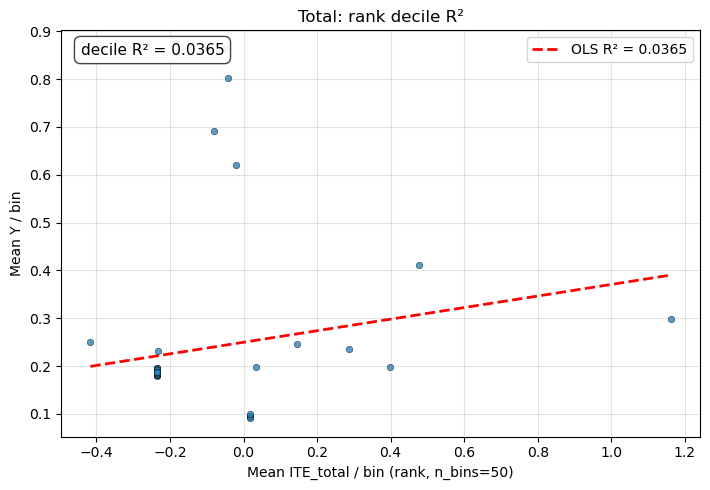

**Total — 分箱明细**（`mean_score`=ITE 均值，`conversion_rate`=Y 均值）

,bin,n,mean_score,conversion_rate
0,0,6535,1.162402,0.299311
1,1,6535,0.476076,0.410406
2,2,6535,0.397925,0.197399
3,3,6535,0.285878,0.235960
4,4,6535,0.145125,0.246366
5,5,6534,0.034434,0.197123
6,6,6535,0.017640,0.092731
7,7,6535,0.017640,0.095639
8,8,6535,0.017640,0.095639
9,9,6535,0.017640,0.091048


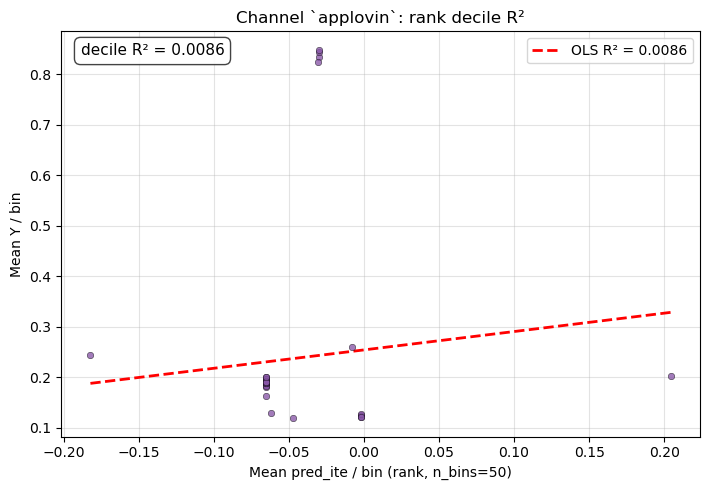

**`applovin` — 分箱明细**

,bin,n,mean_score,conversion_rate
0,0,6535,0.204460,0.201530
1,1,6535,-0.002252,0.123948
2,2,6535,-0.002252,0.123183
3,3,6535,-0.002252,0.121194
4,4,6535,-0.002252,0.126243
5,5,6534,-0.002252,0.120447
6,6,6535,-0.007812,0.260291
7,7,6535,-0.030093,0.833818
8,8,6535,-0.030214,0.844836
9,9,6535,-0.030214,0.848355


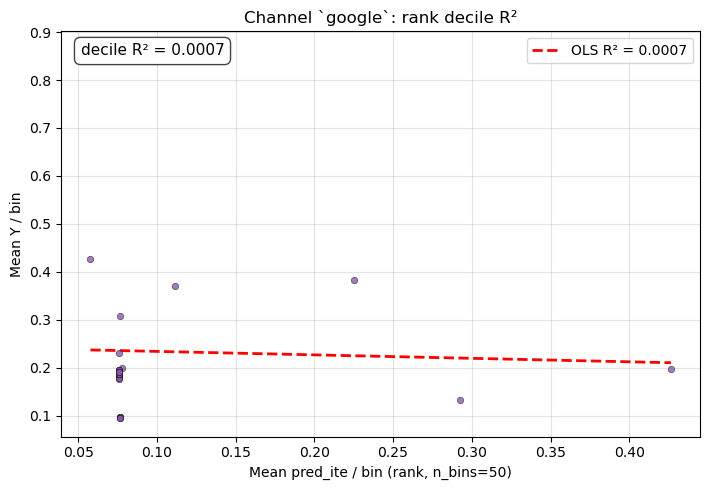

**`google` — 分箱明细**

,bin,n,mean_score,conversion_rate
0,0,6535,0.426436,0.196787
1,1,6535,0.292159,0.132517
2,2,6535,0.225228,0.383015
3,3,6535,0.111185,0.369702
4,4,6535,0.077670,0.200306
5,5,6534,0.076717,0.098255
6,6,6535,0.076717,0.097781
7,7,6535,0.076717,0.097934
8,8,6535,0.076717,0.095180
9,9,6535,0.076717,0.095486


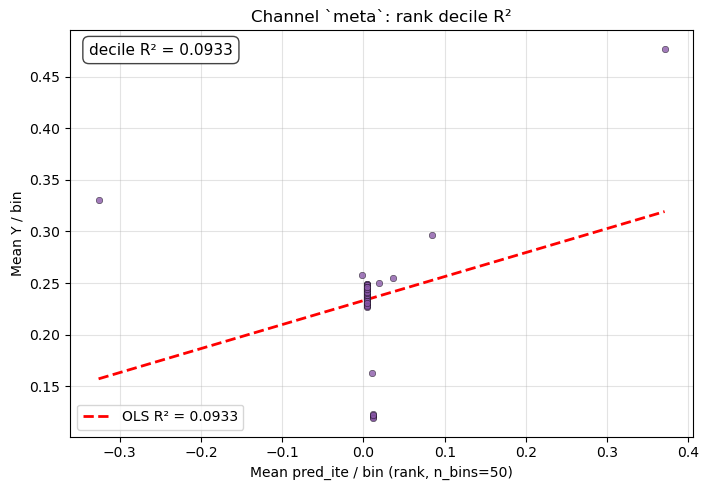

**`meta` — 分箱明细**

,bin,n,mean_score,conversion_rate
0,0,6535,0.370604,0.477276
1,1,6535,0.083960,0.296557
2,2,6535,0.036624,0.255241
3,3,6535,0.018838,0.249579
4,4,6535,0.011418,0.121347
5,5,6534,0.011418,0.120141
6,6,6535,0.011418,0.122877
7,7,6535,0.011418,0.118898
8,8,6535,0.011418,0.121500
9,9,6535,0.010069,0.162816


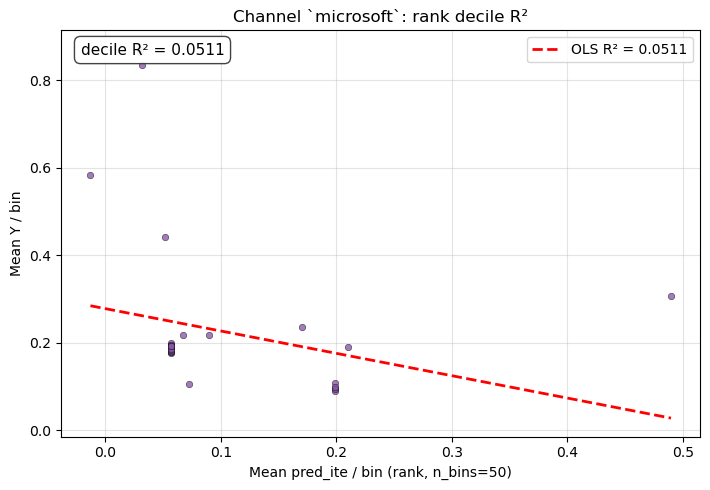

**`microsoft` — 分箱明细**

,bin,n,mean_score,conversion_rate
0,0,6535,0.489780,0.306350
1,1,6535,0.210152,0.190054
2,2,6535,0.198960,0.088906
3,3,6535,0.198960,0.096863
4,4,6535,0.198960,0.106503
5,5,6534,0.198960,0.093358
6,6,6535,0.198960,0.097781
7,7,6535,0.170345,0.235195
8,8,6535,0.090179,0.216373
9,9,6535,0.072237,0.104514


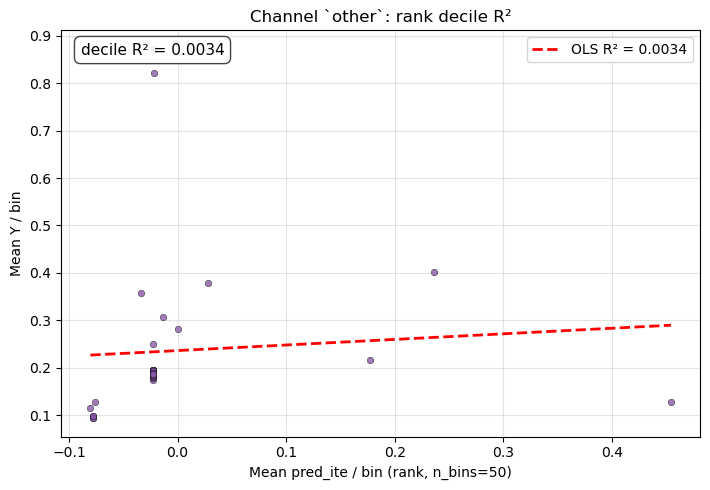

**`other` — 分箱明细**

,bin,n,mean_score,conversion_rate
0,0,6535,0.454275,0.128539
1,1,6535,0.235732,0.402295
2,2,6535,0.177504,0.215608
3,3,6535,0.028183,0.378577
4,4,6535,0.000257,0.281102
5,5,6534,-0.013448,0.307469
6,6,6535,-0.021745,0.820658
7,7,6535,-0.021896,0.869166
8,8,6535,-0.021896,0.872533
9,9,6535,-0.022472,0.250038


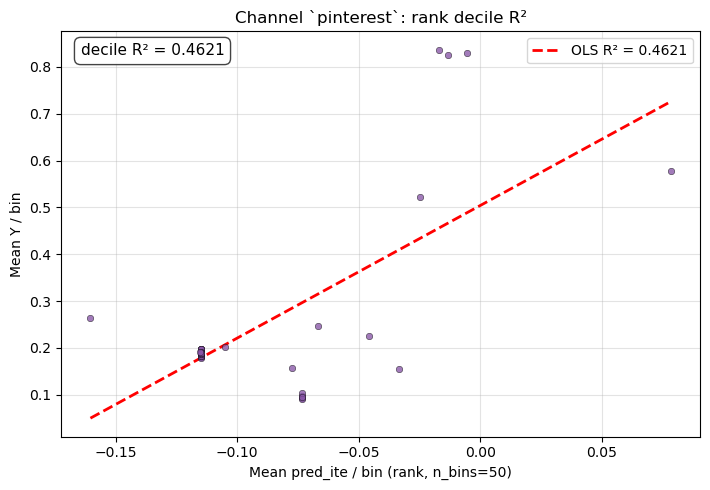

**`pinterest` — 分箱明细**

,bin,n,mean_score,conversion_rate
0,0,6535,0.078313,0.578424
1,1,6535,-0.005652,0.829533
2,2,6535,-0.013509,0.825402
3,3,6535,-0.017047,0.836572
4,4,6535,-0.024935,0.521347
5,5,6534,-0.033586,0.154882
6,6,6535,-0.045898,0.225708
7,7,6535,-0.066647,0.246672
8,8,6535,-0.073452,0.096557
9,9,6535,-0.073452,0.093037


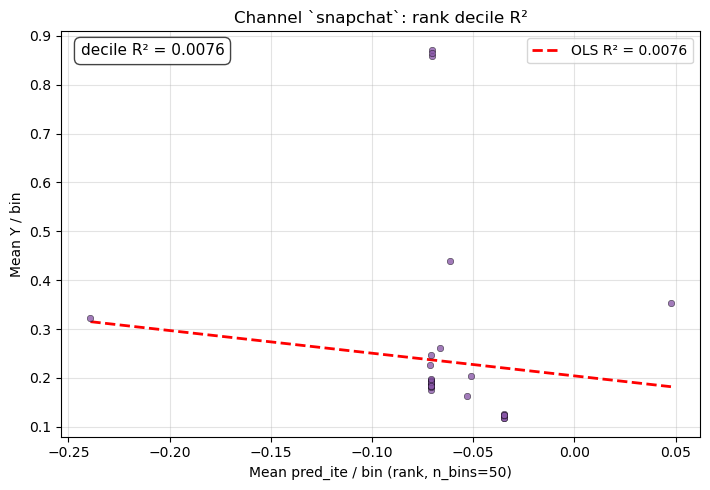

**`snapchat` — 分箱明细**

,bin,n,mean_score,conversion_rate
0,0,6535,0.047656,0.353481
1,1,6535,-0.034792,0.117827
2,2,6535,-0.034957,0.122571
3,3,6535,-0.034957,0.126090
4,4,6535,-0.034957,0.117521
5,5,6534,-0.034957,0.124885
6,6,6535,-0.034966,0.124713
7,7,6535,-0.050921,0.204744
8,8,6535,-0.053009,0.163887
9,9,6535,-0.061412,0.439786


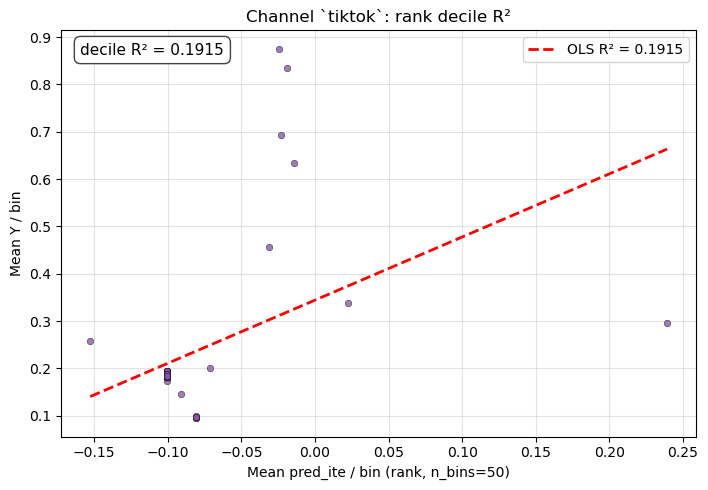

**`tiktok` — 分箱明细**

,bin,n,mean_score,conversion_rate
0,0,6535,0.239265,0.295027
1,1,6535,0.022650,0.337261
2,2,6535,-0.014183,0.633053
3,3,6535,-0.018853,0.834889
4,4,6535,-0.023172,0.694109
5,5,6534,-0.024752,0.875268
6,6,6535,-0.030940,0.455853
7,7,6535,-0.071481,0.200153
8,8,6535,-0.080993,0.098546
9,9,6535,-0.080993,0.094874


In [17]:
# Rank-bin decile R² 图（Total → 各渠道）+ 每图附分箱表
tot_p = EXP_DIR / "test_predictions_total.csv"

if not tot_p.exists():
    display(Markdown("*无 Total CSV，跳过 R² 图。*"))
else:
    dft = pd.read_csv(tot_p)
    if "ITE_total" in dft.columns and "Y" in dft.columns:
        ite_v = dft["ITE_total"].values.astype(float)
        y_v = dft["Y"].values.astype(float)
        cdf_t = _conversion_by_bins_decile(ite_v, y_v, n_bins=N_BINS)
        cdf_ok = cdf_t[cdf_t["n"] > 0]
        r2_rec = _decile_r2_unweighted(cdf_ok["mean_score"].values, cdf_ok["conversion_rate"].values)
        fig, ax = plt.subplots(figsize=(7.2, 5))
        ax.scatter(
            cdf_ok["mean_score"],
            cdf_ok["conversion_rate"],
            s=22,
            alpha=0.78,
            c="#2c7fb8",
            edgecolors="k",
            linewidths=0.35,
            zorder=3,
        )
        xs = cdf_ok["mean_score"].values
        ys = cdf_ok["conversion_rate"].values
        xm, ym = xs.mean(), ys.mean()
        beta = np.sum((xs - xm) * (ys - ym)) / (np.sum((xs - xm) ** 2) + 1e-12)
        alpha = ym - beta * xm
        xx = np.linspace(np.nanmin(xs), np.nanmax(xs), 100)
        ax.plot(xx, alpha + beta * xx, "r--", lw=2, label=f"OLS R² = {r2_rec:.4f}", zorder=2)
        ann = f"decile R² = {r2_rec:.4f}" if r2_rec == r2_rec else "decile R² = n/a"
        ax.text(
            0.03,
            0.97,
            ann,
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#333", alpha=0.92),
            zorder=5,
        )
        ax.set_xlabel(f"Mean ITE_total / bin (rank, n_bins={N_BINS})")
        ax.set_ylabel("Mean Y / bin")
        ax.set_title("Total: rank decile R²")
        ax.legend(loc="best")
        ax.grid(True, alpha=0.35)
        plt.tight_layout()
        plt.show()
        display(Markdown("**Total — 分箱明细**（`mean_score`=ITE 均值，`conversion_rate`=Y 均值）"))
        display(cdf_t)
    else:
        display(Markdown("*Total CSV 缺少 ITE_total / Y。*"))

for ch in chs:
    csvp = EXP_DIR / ch / "test_predictions.csv"
    if not csvp.exists():
        continue
    d = pd.read_csv(csvp)
    if "pred_ite" not in d.columns or "Y" not in d.columns:
        continue
    pred_v = d["pred_ite"].values.astype(float)
    y_v = d["Y"].values.astype(float)
    cdf_c = _conversion_by_bins_decile(pred_v, y_v, n_bins=N_BINS)
    cdf_ok = cdf_c[cdf_c["n"] > 0]
    if len(cdf_ok) < 3:
        display(Markdown(f"*渠道 `{ch}`：有效箱 < 3，跳过 R² 图。*"))
        continue
    r2_ch = _decile_r2_unweighted(cdf_ok["mean_score"].values, cdf_ok["conversion_rate"].values)
    fig, ax = plt.subplots(figsize=(7.2, 5))
    ax.scatter(
        cdf_ok["mean_score"],
        cdf_ok["conversion_rate"],
        s=22,
        alpha=0.78,
        c="#8856a7",
        edgecolors="k",
        linewidths=0.35,
        zorder=3,
    )
    xs = cdf_ok["mean_score"].values
    ys = cdf_ok["conversion_rate"].values
    xm, ym = xs.mean(), ys.mean()
    beta = np.sum((xs - xm) * (ys - ym)) / (np.sum((xs - xm) ** 2) + 1e-12)
    alpha = ym - beta * xm
    xx = np.linspace(np.nanmin(xs), np.nanmax(xs), 100)
    ax.plot(xx, alpha + beta * xx, "r--", lw=2, label=f"OLS R² = {r2_ch:.4f}", zorder=2)
    ann = f"decile R² = {r2_ch:.4f}" if r2_ch == r2_ch else "decile R² = n/a"
    ax.text(
        0.03,
        0.97,
        ann,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#333", alpha=0.92),
        zorder=5,
    )
    ax.set_xlabel(f"Mean pred_ite / bin (rank, n_bins={N_BINS})")
    ax.set_ylabel("Mean Y / bin")
    ax.set_title(f"Channel `{ch}`: rank decile R²")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.show()
    display(Markdown(f"**`{ch}` — 分箱明细**"))
    display(cdf_c)


## Part 4 — Propensity 质量（Val + Test 指标）

- **Val**：各候选的 `log_loss` / `ece` / `auc` 来自 `base_model_scores.json`（与 Part 2 同源）。
- **Test 指标**：`test_predictions.csv` 需含 **`propensity_score`**（由 `run_pipeline` 落盘）。**旧实验无此列**时需重跑。

**重叠图**见末尾 **Part 5**。

**说明**：Total 层无单一 \(e(X)\)，本部分仅 **按渠道** 展示。


In [20]:
import sys
from pathlib import Path


def _ensure_model_build_on_path_part4(exp_dir: Path) -> None:
    p = Path(exp_dir).resolve()
    if p.parent.name == "output":
        grand = p.parent.parent
        if grand.name == "_model_build":
            mb = grand.parent / "model_build"
        elif grand.name == "model_build":
            mb = grand
        else:
            mb = grand
    else:
        mb = p.parent.parent
    s = str(mb)
    if s not in sys.path:
        sys.path.insert(0, s)


_ensure_model_build_on_path_part4(EXP_DIR)

import numpy as np

from dr_learner_pipeline.stages.base_nuisance import evaluate_propensity_predictions

for ch in channels:
    display(Markdown(f"---\n## 渠道 `{ch}` — Propensity（Val + Test 指标）"))

    base = load_json(EXP_DIR / ch / "base_model_scores.json")
    if base and base.get("propensity_scores"):
        dfp = pd.DataFrame(base["propensity_scores"])
        display(Markdown("**倾向模型候选（Val）** — 绿色 = `best_propensity_kind`"))
        display(style_kind_best(dfp, "kind", base.get("best_propensity_kind")))
    else:
        display(Markdown("*无 `base_model_scores.json` 或无 `propensity_scores`。*"))

    csvp = EXP_DIR / ch / "test_predictions.csv"
    if not csvp.exists():
        display(Markdown("*无 `test_predictions.csv`。*"))
        continue
    d = pd.read_csv(csvp)
    if "propensity_score" not in d.columns:
        display(
            Markdown(
                "*无 `propensity_score` 列：请用更新后的 `run_pipeline` 重跑实验以落盘 Test 倾向得分。*"
            )
        )
        continue

    tcol = f"T_{ch}" if f"T_{ch}" in d.columns else None
    if tcol is None:
        tcols = [c for c in d.columns if c.startswith("T_")]
        if not tcols:
            display(Markdown("*无 `T_*` 列。*"))
            continue
        tcol = tcols[0]

    e = d["propensity_score"].to_numpy(dtype=float)
    Tt = d[tcol].to_numpy().astype(int)
    if len(np.unique(Tt)) < 2:
        display(Markdown("*Test 上 T 无 0/1 双组，跳过 Test 指标。*"))
        continue

    met = evaluate_propensity_predictions(e, Tt)
    display(Markdown("**Propensity — Test 指标**"))
    display(pd.DataFrame([met]))

if not channels:
    display(Markdown("*无渠道，跳过 Part 4。*"))


---
## 渠道 `applovin` — Propensity（Val + Test 指标）

**倾向模型候选（Val）** — 绿色 = `best_propensity_kind`

,kind,log_loss,ece
0,lr,0.228537,0.018063
1,xgb,0.232011,0.023124


*无 `propensity_score` 列：请用更新后的 `run_pipeline` 重跑实验以落盘 Test 倾向得分。*

---
## 渠道 `google` — Propensity（Val + Test 指标）

...

*无 `propensity_score` 列：请用更新后的 `run_pipeline` 重跑实验以落盘 Test 倾向得分。*

---
## 渠道 `tiktok` — Propensity（Val + Test 指标）

**倾向模型候选（Val）** — 绿色 = `best_propensity_kind`

,kind,log_loss,ece
0,lr,0.002061,0.000162
1,xgb,0.001874,0.000195


*无 `propensity_score` 列：请用更新后的 `run_pipeline` 重跑实验以落盘 Test 倾向得分。*

## Part 5 — Propensity score 重叠（可视化专节）

本节专注 **Test** 上拟合倾向模型给出的 **`propensity_score`**（即 \(\hat e(X)=P(T=1\mid X)\)）在 **T=0** 与 **T=1** 两组下的分布：

- **左图**：同一组 `bins` 上的密度直方图重叠，用于观察 **common support**（两分布是否严重分离）。
- **右图**：箱线图对比两组 \(\hat e\) 的分位与离群点。
- 数据与 **Part 4** 相同；需 `test_predictions.csv` 含 **`propensity_score`** 列。


In [19]:
import sys
from pathlib import Path

from IPython.display import Markdown, display


def _ensure_model_build_on_path_p5(exp_dir: Path) -> None:
    p = Path(exp_dir).resolve()
    if p.parent.name == "output":
        grand = p.parent.parent
        if grand.name == "_model_build":
            mb = grand.parent / "model_build"
        elif grand.name == "model_build":
            mb = grand
        else:
            mb = grand
    else:
        mb = p.parent.parent
    s = str(mb)
    if s not in sys.path:
        sys.path.insert(0, s)


_ensure_model_build_on_path_p5(EXP_DIR)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 重叠直方图共用边界（0–1）
PROPENSITY_OVERLAP_BINS = 40

for ch in channels:
    display(Markdown(f"---\n## 渠道 `{ch}` — Propensity 重叠（Test）"))

    csvp = EXP_DIR / ch / "test_predictions.csv"
    if not csvp.exists():
        display(Markdown("*无 `test_predictions.csv`。*"))
        continue
    d = pd.read_csv(csvp)
    if "propensity_score" not in d.columns:
        display(
            Markdown(
                "*无 `propensity_score` 列：请用更新后的 `run_pipeline` 重跑实验。*"
            )
        )
        continue

    tcol = f"T_{ch}" if f"T_{ch}" in d.columns else None
    if tcol is None:
        tcols = [c for c in d.columns if c.startswith("T_")]
        if not tcols:
            display(Markdown("*无 `T_*` 列。*"))
            continue
        tcol = tcols[0]

    e = d["propensity_score"].to_numpy(dtype=float)
    Tt = d[tcol].to_numpy().astype(int)
    if len(np.unique(Tt)) < 2:
        display(Markdown("*Test 上 T 无 0/1 双组，跳过重叠图。*"))
        continue

    e0, e1 = e[Tt == 0], e[Tt == 1]
    bins = np.linspace(0, 1, PROPENSITY_OVERLAP_BINS + 1)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

    ax = axes[0]
    ax.hist(
        e0,
        bins=bins,
        density=True,
        alpha=0.55,
        label=f"T=0 (n={len(e0)})",
        color="#3498db",
    )
    ax.hist(
        e1,
        bins=bins,
        density=True,
        alpha=0.55,
        label=f"T=1 (n={len(e1)})",
        color="#e74c3c",
    )
    ax.set_xlabel("propensity_score (P(T=1|X))")
    ax.set_ylabel("density")
    ax.set_title(f"`{ch}` — 分布重叠")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)

    ax2 = axes[1]
    bp = ax2.boxplot([e0, e1], labels=["T=0", "T=1"], patch_artist=True)
    for patch, color in zip(bp["boxes"], ("#3498db", "#e74c3c")):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
    ax2.set_ylabel("propensity_score")
    ax2.set_title(f"`{ch}` — 分位对比")
    ax2.grid(True, axis="y", alpha=0.3)

    plt.show()

    sm = pd.DataFrame(
        [
            {
                "group": "T=0",
                "n": len(e0),
                "mean_e": float(np.mean(e0)),
                "median_e": float(np.median(e0)),
            },
            {
                "group": "T=1",
                "n": len(e1),
                "mean_e": float(np.mean(e1)),
                "median_e": float(np.median(e1)),
            },
        ]
    )
    display(Markdown("**摘要（Test）**"))
    display(sm)

if not channels:
    display(Markdown("*无渠道，跳过 Part 5。*"))


---
## 渠道 `applovin` — Propensity 重叠（Test）

*无 `propensity_score` 列：请用更新后的 `run_pipeline` 重跑实验。*

---
## 渠道 `google` — Propensity 重叠（Test）

*无 `propensity_score` 列：请用更新后的 `run_pipeline` 重跑实验。*

---
## 渠道 `meta` — Propensity 重叠（Test）

...

*无 `propensity_score` 列：请用更新后的 `run_pipeline` 重跑实验。*

---
## 渠道 `snapchat` — Propensity 重叠（Test）

*无 `propensity_score` 列：请用更新后的 `run_pipeline` 重跑实验。*

---
## 渠道 `tiktok` — Propensity 重叠（Test）

*无 `propensity_score` 列：请用更新后的 `run_pipeline` 重跑实验。*